# Calculation of Scores
What do we need?
Taskname, Occupation, Label (A0-A4), Importance Scores

In [18]:
#import matplotlib.pyplot as plt
import pandas as pd
import math

In [19]:
df_tasks = pd.read_excel('TaskStatements.xlsx')
df_im_tasks = pd.read_excel("Task Ratings.xlsx")
df_labeled_tasks = pd.read_fwf(
    f"merged_output_full_no_patents.txt",
    colspecs= [(0,7),(8,14),(15,120),(121,453),(454,None)],
    header=0,
    names=['Task ID', 'Label', 'occupation', 'task_description', 'label_explanation']
)
df_labeled_tasks['Task ID'] = pd.to_numeric(df_labeled_tasks['Task ID'])
df_labeled_tasks.head(5)

,Task ID,Label,occupation,task_description,label_explanation
0,1,A3,Sales Managers,Resolve customer complaints regarding sales an...,"AGI could autonomously understand complaints, ..."
1,2,A2,Sales Managers,Monitor customer preferences to determine focu...,Task is predominantly cognitive data analysis ...
2,3,A3,Sales Managers,Direct and coordinate activities involving sal...,The role is primarily cognitive and managerial...
3,4,A4,Sales Managers,Determine price schedules and discount rates.,"Pricing decisions combine analytics, optimizat..."
4,5,A4,Sales Managers,Review operational records and reports to proj...,The task is purely data analysis and profitabi...


In [20]:
#Read full list of tasks and assign each one the label A0
df_tasks["Label"] = "P"
df_tasks["Label_Numeric"] = float(0)
print(df_tasks.shape)
print(df_labeled_tasks.shape)


(18796, 10)
(16916, 5)


In [21]:
#Read the full list of tasks and importance scores, add the scores to the df.tasks table
df_im_tasks = df_im_tasks[df_im_tasks['Scale ID'].str.contains('IM', na=False)]
# Select only the 'Task ID' and 'Data Value' columns from df_im_tasks for merging
df_im_tasks_subset = df_im_tasks[['Task ID', 'Data Value']]
df_tasks = pd.merge(df_tasks, df_im_tasks_subset, how="left", on='Task ID')
df_tasks.rename(columns={"Data Value":"Importance Score"})
print(df_tasks.shape)

(18796, 11)


In [22]:
def assign_numeric_Label(label):
  match (label):
    case "P":
      return 0;
    case "A0":
      return 0;
    case "A1":
      return 0.25;
    case "A2":
      return 0.5;
    case "A3":
      return 0.75;
    case "A4":
      return 1;

In [23]:
#Read the fully labeled list of Tasks, assign the values to the label category from the df before and add numeric values for each label

# Merge df_tasks with df_labeled_tasks on 'Task ID' to bring in the new 'Label' values
df_tasks = pd.merge(df_tasks, df_labeled_tasks[['Task ID', 'Label']], how="left", on="Task ID", suffixes=('_original', '_from_labeled'))

# Update the 'Label' column in df_tasks with values from 'Label_from_labeled' where available,
# otherwise keep the original 'Label' (which is '0' for unlabeled tasks)
df_tasks['Label'] = df_tasks['Label_from_labeled'].fillna(df_tasks['Label_original'])

# Drop the temporary columns created during the merge
df_tasks.drop(columns=['Label_original', 'Label_from_labeled'], inplace=True)

for i in range(df_tasks.shape[0]):
  df_tasks.loc[i,"Label_Numeric"] = assign_numeric_Label(df_tasks.loc[i,"Label"])

print(f'Task number should be 18769, is {df_tasks.shape[0]}')

Task number should be 18769, is 18796


In [24]:
# Set Tasks without an importance score to a specific number
#df_tasks[pd.isnull(df_tasks['Data Value'])]
df_tasks = df_tasks.fillna({'Data Value': 1})
df_tasks

,O*NET-SOC Code,Title,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source,Label_Numeric,Data Value,Label
0,11-1011.00,Chief Executives,8823,Direct or coordinate an organization's financi...,Core,95.0,08/2023,Incumbent,0.75,4.52,A3
1,11-1011.00,Chief Executives,8824,"Confer with board members, organization offici...",Core,95.0,08/2023,Incumbent,0.75,4.32,A3
2,11-1011.00,Chief Executives,8827,"Prepare budgets for approval, including those ...",Core,95.0,08/2023,Incumbent,0.75,4.30,A3
3,11-1011.00,Chief Executives,8826,"Direct, plan, or implement policies, objective...",Core,94.0,08/2023,Incumbent,1.00,4.24,A4
4,11-1011.00,Chief Executives,8834,Prepare or present reports concerning activiti...,Core,95.0,08/2023,Incumbent,0.75,4.17,A3
...,...,...,...,...,...,...,...,...,...,...,...
18791,53-7121.00,"Tank Car, Truck, and Ship Loaders",12807,Unload cars containing liquids by connecting h...,Supplemental,85.0,08/2019,Incumbent,0.75,4.08,A3
18792,53-7121.00,"Tank Car, Truck, and Ship Loaders",12804,"Clean interiors of tank cars or tank trucks, u...",Supplemental,85.0,08/2019,Incumbent,0.75,4.02,A3
18793,53-7121.00,"Tank Car, Truck, and Ship Loaders",12803,Lower gauge rods into tanks or read meters to ...,Supplemental,85.0,08/2019,Incumbent,0.00,3.88,A0
18794,53-7121.00,"Tank Car, Truck, and Ship Loaders",12805,Operate conveyors and equipment to transfer gr...,Supplemental,85.0,08/2019,Incumbent,0.75,3.87,A3


In [25]:
df_automation_score = df_tasks.copy(deep = True)
df_automation_score['Weighted Labelscore'] = df_automation_score['Data Value'] * df_automation_score['Label_Numeric']
df_automation_score['Absolute_AGI_Importance'] = 0.0;
df_automation_score['Absolute_Non_AGI_Importance'] = 0.0;
#For Augmentation: Calculate the total Importance of AGI affected Tasks and Non AGI affected Tasks
for i in range(df_automation_score.shape[0]):
  df_automation_score.loc[i,"Absolute_AGI_Importance"] = df_automation_score.loc[i,'Data Value'] * (0 if df_automation_score.loc[i,'Label_Numeric']  ==0  else 1)
  df_automation_score.loc[i,"Absolute_Non_AGI_Importance"] = df_automation_score.loc[i,'Data Value'] * (1 if df_automation_score.loc[i,'Label_Numeric']  ==0 else 0)
# And then aggregating these weighted scores
occupation_automation_scores = df_automation_score.groupby('O*NET-SOC Code').agg(
    Sum_Weighted_Data_Value=('Weighted Labelscore', 'sum'),
    Sum_Data_Value=('Data Value', 'sum'),
    Absolute_AGI_Importance_Score=('Absolute_AGI_Importance','sum'),
    Absolute_Non_AGI_Importance_Score=('Absolute_Non_AGI_Importance','sum'),
).reset_index()
#Then divide by the total Importance scores
occupation_automation_scores['Automation_Score'] = occupation_automation_scores['Sum_Weighted_Data_Value'] / occupation_automation_scores['Sum_Data_Value']
occupation_automation_scores = occupation_automation_scores.rename(columns={'Sum_Weighted_Data_Value':'Weighted_Labelscore', 'Sum_Data_Value':'Sum_Importance_Scores'})
#Now calculate the Augmenation score score (1 - (share_occ_tasks_A1-A4^2 - share_occ_tasks_A0/P^2), each share weighted with Importance scores
# Share is calculated as Sum_Importance scores of A1-A4/ Sum_Importance_Scores and same for Sum_Importance scores of A0 and P
occupation_automation_scores['Augmentation_Score'] = 1- (
    (occupation_automation_scores['Absolute_AGI_Importance_Score'] / occupation_automation_scores['Sum_Importance_Scores']) ** 2
    + (occupation_automation_scores['Absolute_Non_AGI_Importance_Score'] / occupation_automation_scores['Sum_Importance_Scores']) ** 2
)
display(occupation_automation_scores.head())

,O*NET-SOC Code,Weighted_Labelscore,Sum_Importance_Scores,Absolute_AGI_Importance_Score,Absolute_Non_AGI_Importance_Score,Automation_Score,Augmentation_Score
0,11-1011.00,93.9050,122.48,122.48,0.0,0.766697,0.000000
1,11-1011.03,54.2575,67.63,67.63,0.0,0.802270,0.000000
2,11-1021.00,41.0250,62.83,52.03,10.8,0.652952,0.284691
3,11-1031.00,20.2500,30.00,29.00,1.0,0.675000,0.064444
4,11-2011.00,67.2050,86.53,84.53,2.0,0.776667,0.045158


In [26]:
label_counts_per_occupation = pd.pivot_table(df_tasks, index='O*NET-SOC Code', columns='Label', aggfunc='size', fill_value=0)
display(label_counts_per_occupation.head(15))

Label,A0,A1,A2,A3,A4,P
O*NET-SOC Code,,,,,,
11-1011.00,0,0,0,29,2,0
11-1011.03,0,0,0,14,4,0
11-1021.00,1,0,0,12,2,2
11-1031.00,1,1,4,24,0,0
11-2011.00,1,0,4,16,8,1
11-2021.00,0,0,2,12,6,0
11-2022.00,1,0,2,11,3,0
11-2032.00,0,0,5,14,0,1
11-2033.00,0,0,2,10,4,0


In [27]:
auto_aug_final_df = occupation_automation_scores.merge(label_counts_per_occupation, how='left', on='O*NET-SOC Code')
auto_aug_final_df = auto_aug_final_df.merge(df_tasks[['O*NET-SOC Code', 'Title']].drop_duplicates(), how='left', on='O*NET-SOC Code')
cols = ['Title'] + [c for c in auto_aug_final_df.columns if c != 'Title']
auto_aug_final_df = auto_aug_final_df[cols]

auto_aug_final_df.head(10)

,Title,O*NET-SOC Code,Weighted_Labelscore,Sum_Importance_Scores,Absolute_AGI_Importance_Score,Absolute_Non_AGI_Importance_Score,Automation_Score,Augmentation_Score,A0,A1,A2,A3,A4,P
0,Chief Executives,11-1011.00,93.9050,122.48,122.48,0.0,0.766697,0.000000,0,0,0,29,2,0
1,Chief Sustainability Officers,11-1011.03,54.2575,67.63,67.63,0.0,0.802270,0.000000,0,0,0,14,4,0
2,General and Operations Managers,11-1021.00,41.0250,62.83,52.03,10.8,0.652952,0.284691,1,0,0,12,2,2
3,Legislators,11-1031.00,20.2500,30.00,29.00,1.0,0.675000,0.064444,1,1,4,24,0,0
4,Advertising and Promotions Managers,11-2011.00,67.2050,86.53,84.53,2.0,0.776667,0.045158,1,0,4,16,8,1
5,Marketing Managers,11-2021.00,54.6775,68.59,68.59,0.0,0.797164,0.000000,0,0,2,12,6,0
6,Sales Managers,11-2022.00,45.7150,63.40,59.90,3.5,0.721057,0.104315,1,0,2,11,3,0
7,Public Relations Managers,11-2032.00,13.0000,20.00,19.00,1.0,0.650000,0.095000,0,0,5,14,0,1
8,Fundraising Managers,11-2033.00,46.4750,59.87,59.87,0.0,0.776265,0.000000,0,0,2,10,4,0
9,Administrative Services Managers,11-3012.00,31.4525,39.24,39.24,0.0,0.801542,0.000000,0,0,3,10,5,0


In [28]:
#Export
auto_aug_final_df.to_csv("Occupations_With_Automation_Augmentation_Scores.csv")


#Analysis: Sorting and Ranking, Dirtribution Graphs

In [29]:
import pandas as pd
df_view = pd.read_csv("Occupations_With_Automation_Augmentation_Scores.csv")
df_view.head(3)

,Unnamed: 0,Title,O*NET-SOC Code,Weighted_Labelscore,Sum_Importance_Scores,Absolute_AGI_Importance_Score,Absolute_Non_AGI_Importance_Score,Automation_Score,Augmentation_Score,A0,A1,A2,A3,A4,P
0,0,Chief Executives,11-1011.00,93.9050,122.48,122.48,0.0,0.766697,0.000000,0,0,0,29,2,0
1,1,Chief Sustainability Officers,11-1011.03,54.2575,67.63,67.63,0.0,0.802270,0.000000,0,0,0,14,4,0
2,2,General and Operations Managers,11-1021.00,41.0250,62.83,52.03,10.8,0.652952,0.284691,1,0,0,12,2,2


### Ranking

In [30]:
df_view = df_view.sort_values('Automation_Score', ascending=False).reset_index(drop=True)
df_view['Automation Rank'] = 0
for i in range(df_view.shape[0]):
  df_view.loc[i,'Automation Rank'] = i+1
df_view.head(10)

,Unnamed: 0,Title,O*NET-SOC Code,Weighted_Labelscore,Sum_Importance_Scores,Absolute_AGI_Importance_Score,Absolute_Non_AGI_Importance_Score,Automation_Score,Augmentation_Score,A0,A1,A2,A3,A4,P,Automation Rank
0,132,Mathematicians,15-2021.00,44.9675,45.66,45.66,0.00,0.984834,0.000000,0,0,0,1,11,0,1
1,644,"Graders and Sorters, Agricultural Products",45-2041.00,21.0625,22.17,22.17,0.00,0.950045,0.000000,0,0,0,1,4,0,2
2,369,"Poets, Lyricists and Creative Writers",27-3043.05,58.3700,63.95,60.95,3.00,0.912744,0.089422,1,0,1,1,13,0,3
3,368,Writers and Authors,27-3043.00,39.4700,43.82,43.82,0.00,0.900730,0.000000,0,0,1,6,13,0,4
4,640,Statistical Assistants,43-9111.00,51.2400,58.59,58.59,0.00,0.874552,0.000000,0,0,3,1,10,0,5
5,134,Statisticians,15-2041.00,67.3650,77.60,70.26,7.34,0.868106,0.171282,0,0,1,1,15,2,6
6,76,Project Management Specialists,13-1082.00,17.2500,20.00,20.00,0.00,0.862500,0.000000,0,0,2,7,11,0,7
7,82,Market Research Analysts and Marketing Special...,13-1161.00,44.5225,51.83,47.47,4.36,0.859010,0.154090,0,0,0,3,9,1,8
8,218,Climate Change Policy Analysts,19-2041.01,49.1375,57.27,57.27,0.00,0.857997,0.000000,0,0,0,8,6,0,9
9,88,Accountants and Auditors,13-2011.00,92.0600,107.69,103.19,4.50,0.854861,0.080081,0,0,2,7,19,1,10


In [31]:
df_view = df_view.sort_values(by=['Augmentation_Score', 'Automation_Score'], ascending=[False, False]).reset_index(drop=True)
df_view['Augmentation Rank'] = 0
for i in range(df_view.shape[0]):
  df_view.loc[i,'Augmentation Rank'] = i+1
df_view.head(3)

,Unnamed: 0,Title,O*NET-SOC Code,Weighted_Labelscore,Sum_Importance_Scores,Absolute_AGI_Importance_Score,Absolute_Non_AGI_Importance_Score,Automation_Score,Augmentation_Score,A0,A1,A2,A3,A4,P,Automation Rank,Augmentation Rank
0,447,Emergency Medical Technicians,29-2042.00,4.000,12.00,6.00,6.00,0.333333,0.500000,5,0,2,4,0,1,711,1
1,550,Crematory Operators,39-4012.00,4.000,12.00,6.00,6.00,0.333333,0.500000,6,1,0,5,0,0,712,2
2,893,Subway and Streetcar Operators,53-4041.00,14.985,45.64,22.76,22.88,0.328330,0.499997,2,1,0,4,0,3,719,3


In [32]:
df_view = df_view.rename(columns={"Automation_Score": 'Automation Score'})
cols = [c for c in df_view.columns if c != 'Automation Score'] + ['Automation Score']
df_view = df_view[cols]
cols = [c for c in df_view.columns if c != 'Automation Rank'] + ['Automation Rank']
df_view = df_view[cols]
df_view.head(3)

,Unnamed: 0,Title,O*NET-SOC Code,Weighted_Labelscore,Sum_Importance_Scores,Absolute_AGI_Importance_Score,Absolute_Non_AGI_Importance_Score,Augmentation_Score,A0,A1,A2,A3,A4,P,Augmentation Rank,Automation Score,Automation Rank
0,447,Emergency Medical Technicians,29-2042.00,4.000,12.00,6.00,6.00,0.500000,5,0,2,4,0,1,1,0.333333,711
1,550,Crematory Operators,39-4012.00,4.000,12.00,6.00,6.00,0.500000,6,1,0,5,0,0,2,0.333333,712
2,893,Subway and Streetcar Operators,53-4041.00,14.985,45.64,22.76,22.88,0.499997,2,1,0,4,0,3,3,0.328330,719


In [33]:
df_aii = pd.read_csv("aii_by_occupation.csv")
df_view = pd.merge(df_view,df_aii[["Title","AII"]],how="left", on="Title")
df_view = df_view.sort_values(by=['AII'], ascending=[False], kind='stable').reset_index(drop=True)
df_view['AII Rank'] = 0
for i in range(df_view.shape[0]):
  df_view.loc[i,'AII Rank'] = i+1
df_view.head(10)

,Unnamed: 0,Title,O*NET-SOC Code,Weighted_Labelscore,Sum_Importance_Scores,Absolute_AGI_Importance_Score,Absolute_Non_AGI_Importance_Score,Augmentation_Score,A0,A1,A2,A3,A4,P,Augmentation Rank,Automation Score,Automation Rank,AII,AII Rank
0,446,Medical Dosimetrists,29-2036.00,8.2900,79.14,15.13,64.01,0.309261,1,1,1,2,0,14,482,0.104751,899,0.736842,1
1,878,Air Traffic Controllers,53-2021.00,22.5225,102.89,30.03,72.86,0.413360,0,0,0,7,0,16,337,0.218899,839,0.695652,2
2,342,Special Effects Artists and Animators,27-1014.00,13.5100,48.10,16.58,31.52,0.451763,0,0,0,3,1,9,247,0.280873,773,0.692308,3
3,619,Public Safety Telecommunicators,43-5031.00,25.5175,82.13,35.72,46.41,0.491529,0,1,1,4,2,10,90,0.310696,737,0.555556,4
4,178,Solar Energy Systems Engineers,17-2199.11,16.2625,48.76,22.87,25.89,0.498082,0,0,1,5,0,7,42,0.333521,710,0.538462,5
5,441,Cardiovascular Technologists and Technicians,29-2031.00,21.2150,94.45,34.21,60.24,0.462024,2,1,4,1,2,11,216,0.224616,832,0.523810,6
6,461,Ophthalmic Medical Technologists,29-2099.05,28.6275,130.34,51.31,79.03,0.477385,2,3,4,6,0,16,162,0.219637,838,0.516129,7
7,454,Ophthalmic Medical Technicians,29-2057.00,15.1525,87.25,31.08,56.17,0.458653,2,3,3,2,0,10,224,0.173668,868,0.500000,8
8,445,Magnetic Resonance Imaging Technologists,29-2035.00,27.6325,106.62,47.89,58.73,0.494832,2,3,2,6,0,11,73,0.259168,795,0.458333,9
9,240,Precision Agriculture Technicians,19-4012.01,31.1750,83.08,40.74,42.34,0.499815,1,1,2,4,4,10,11,0.375241,665,0.454545,10


In [34]:
##Rank diff
df_view['Auto-AII Rank-Diff'] = 0
for i in range(df_view.shape[0]):
  df_view.loc[i,'Auto-AII Rank-Diff'] = df_view.loc[i,'AII Rank']-df_view.loc[i,'Automation Rank']
df_view['Aug-AII Rank-Diff'] = 0
for i in range(df_view.shape[0]):
  df_view.loc[i,'Aug-AII Rank-Diff'] = df_view.loc[i,'AII Rank']-df_view.loc[i,'Augmentation Rank']
df_view

,Unnamed: 0,Title,O*NET-SOC Code,Weighted_Labelscore,Sum_Importance_Scores,Absolute_AGI_Importance_Score,Absolute_Non_AGI_Importance_Score,Augmentation_Score,A0,A1,...,A3,A4,P,Augmentation Rank,Automation Score,Automation Rank,AII,AII Rank,Auto-AII Rank-Diff,Aug-AII Rank-Diff
0,446,Medical Dosimetrists,29-2036.00,8.2900,79.14,15.13,64.01,0.309261,1,1,...,2,0,14,482,0.104751,899,0.736842,1,-898,-481
1,878,Air Traffic Controllers,53-2021.00,22.5225,102.89,30.03,72.86,0.413360,0,0,...,7,0,16,337,0.218899,839,0.695652,2,-837,-335
2,342,Special Effects Artists and Animators,27-1014.00,13.5100,48.10,16.58,31.52,0.451763,0,0,...,3,1,9,247,0.280873,773,0.692308,3,-770,-244
3,619,Public Safety Telecommunicators,43-5031.00,25.5175,82.13,35.72,46.41,0.491529,0,1,...,4,2,10,90,0.310696,737,0.555556,4,-733,-86
4,178,Solar Energy Systems Engineers,17-2199.11,16.2625,48.76,22.87,25.89,0.498082,0,0,...,5,0,7,42,0.333521,710,0.538462,5,-705,-37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
918,258,Marriage and Family Therapists,21-1013.00,35.4275,59.93,59.93,0.00,0.000000,0,1,...,7,0,0,919,0.591148,359,0.000000,919,560,0
919,781,"Extruding and Drawing Machine Setters, Operato...",51-4021.00,35.1525,62.86,62.86,0.00,0.000000,0,5,...,7,1,0,920,0.559219,400,0.000000,920,520,0
920,398,Art Therapists,29-1129.01,54.1675,98.34,98.34,0.00,0.000000,0,1,...,4,1,0,921,0.550819,418,0.000000,921,503,0
921,321,"Special Education Teachers, Elementary School",25-2056.00,69.0150,130.76,130.76,0.00,0.000000,0,2,...,5,0,0,922,0.527799,447,0.000000,922,475,0


### Visualizations, Graphs

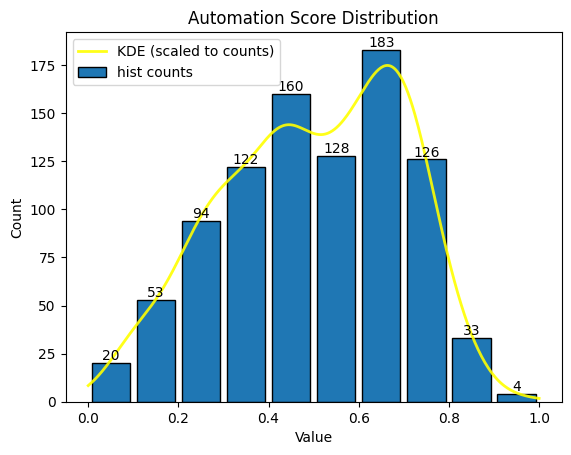

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# sample data
data = df_view["Automation Score"]

# define non-uniform bins (edges)
bins = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

# histogram counts (density=False for counts)
hist_vals, edges = np.histogram(data, bins=bins, density=False)
left = edges[:-1]; widths = edges[1:]-edges[:-1]
gap = 0.85
bar_widths = widths * gap
bar_left = left + (widths - bar_widths)/2

fig, ax = plt.subplots()
bar_container = ax.bar(bar_left, hist_vals, width=bar_widths, align='edge',
                      edgecolor='k', label='hist counts') # Added alpha for transparency

kde = gaussian_kde(data)
x = np.linspace(edges[0], edges[-1], 400)

# Scale KDE to match the count histogram
kde_scaled = kde(x) * len(data) * widths.mean()
ax.plot(x, kde_scaled, color='yellow', lw=2, label='KDE (scaled to counts)', alpha=0.9)

ax.bar_label(bar_container, fmt='{:,.0f}')
ax.set_title("Automation Score Distribution")
ax.set_xlabel('Value'); ax.set_ylabel('Count')
ax.legend(); plt.show()

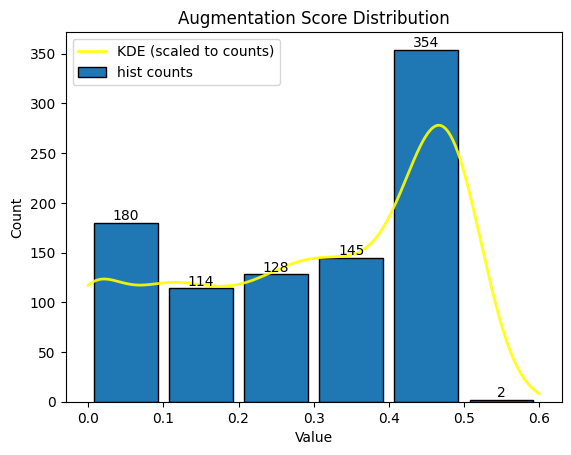

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# sample data
data = df_view["Augmentation_Score"]

# define non-uniform bins (edges)
bins = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])

# histogram counts (density=False for counts)
hist_vals, edges = np.histogram(data, bins=bins, density=False)
left = edges[:-1]; widths = edges[1:]-edges[:-1]
gap = 0.85
bar_widths = widths * gap
bar_left = left + (widths - bar_widths)/2

fig, ax = plt.subplots()
bar_container = ax.bar(bar_left, hist_vals, width=bar_widths, align='edge',
                      edgecolor='k', label='hist counts') # Added alpha for transparency

kde = gaussian_kde(data)
x = np.linspace(edges[0], edges[-1], 400)

# Scale KDE to match the count histogram
kde_scaled = kde(x) * len(data) * widths.mean()
ax.plot(x, kde_scaled, color='yellow', lw=2, label='KDE (scaled to counts)', alpha=0.9)

ax.bar_label(bar_container, fmt='{:,.0f}')
ax.set_title("Augmentation Score Distribution")
ax.set_xlabel('Value'); ax.set_ylabel('Count')
ax.legend(); plt.show()

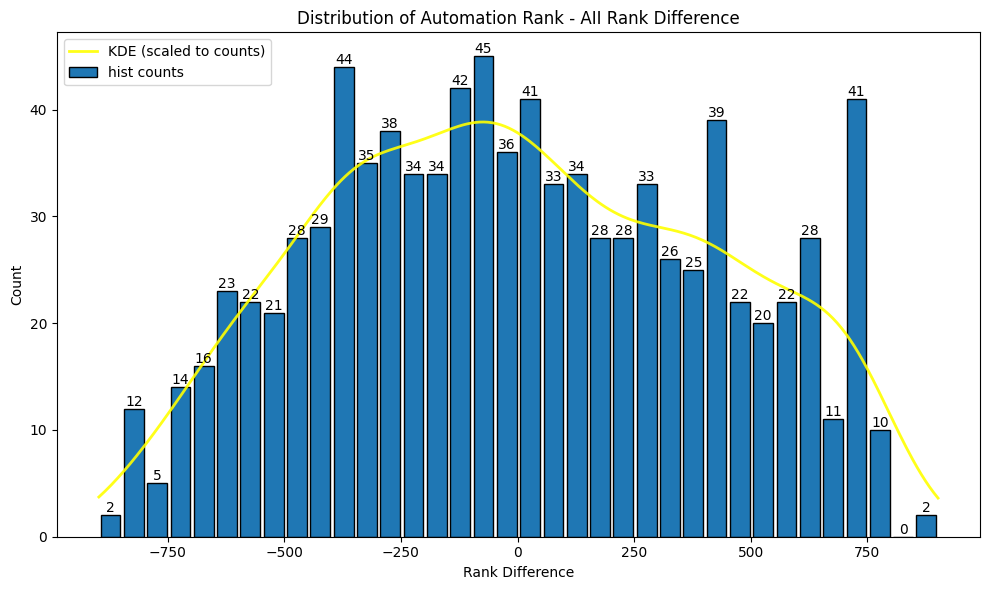

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Sample data for 'Auto-AII Rank-Diff'
data_auto_aii_diff = df_view["Auto-AII Rank-Diff"]

# Define bins (edges) suitable for rank differences, covering the expected range
min_rank_diff = data_auto_aii_diff.min()
max_rank_diff = data_auto_aii_diff.max()
bins_auto_aii_diff = np.arange(min_rank_diff, max_rank_diff + 50, 50) # Increment by 50 for a reasonable number of bins

# Histogram counts (density=False for counts)
hist_vals_auto, edges_auto = np.histogram(data_auto_aii_diff, bins=bins_auto_aii_diff, density=False)
left_auto = edges_auto[:-1]; widths_auto = edges_auto[1:]-edges_auto[:-1]
gap = 0.85
bar_widths_auto = widths_auto * gap
bar_left_auto = left_auto + (widths_auto - bar_widths_auto)/2

fig_auto, ax_auto = plt.subplots(figsize=(10, 6))
bar_container_auto = ax_auto.bar(bar_left_auto, hist_vals_auto, width=bar_widths_auto, align='edge',
                                 edgecolor='k', label='hist counts')

# KDE plot
if len(data_auto_aii_diff) > 1 and np.std(data_auto_aii_diff) > 0: # Ensure enough data and variability for KDE
    kde_auto = gaussian_kde(data_auto_aii_diff)
    x_auto = np.linspace(edges_auto[0], edges_auto[-1], 400)
    kde_scaled_auto = kde_auto(x_auto) * len(data_auto_aii_diff) * widths_auto.mean()
    ax_auto.plot(x_auto, kde_scaled_auto, color='yellow', lw=2, label='KDE (scaled to counts)', alpha=0.9)

ax_auto.bar_label(bar_container_auto, fmt='{:,.0f}')
ax_auto.set_title("Distribution of Automation Rank - AII Rank Difference")
ax_auto.set_xlabel('Rank Difference'); ax_auto.set_ylabel('Count')
ax_auto.legend();
plt.tight_layout()
plt.show()

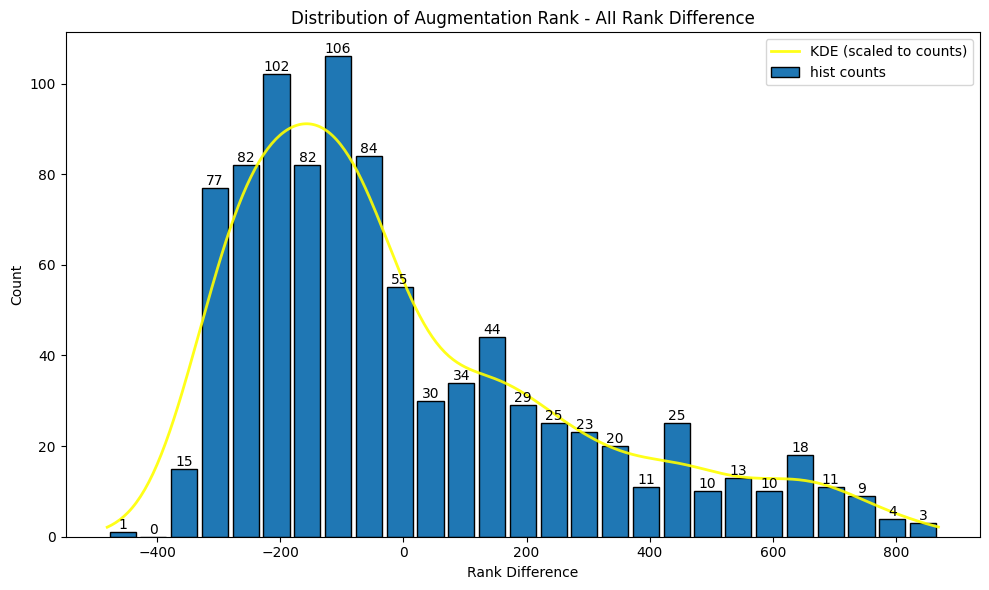

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Sample data for 'Aug-AII Rank-Diff'
data_aug_aii_diff = df_view["Aug-AII Rank-Diff"]

# Define bins (edges) suitable for rank differences, covering the expected range
min_rank_diff = data_aug_aii_diff.min()
max_rank_diff = data_aug_aii_diff.max()
bins_aug_aii_diff = np.arange(min_rank_diff, max_rank_diff + 50, 50) # Increment by 50 for a reasonable number of bins

# Histogram counts (density=False for counts)
hist_vals_aug, edges_aug = np.histogram(data_aug_aii_diff, bins=bins_aug_aii_diff, density=False)
left_aug = edges_aug[:-1]; widths_aug = edges_aug[1:]-edges_aug[:-1]
gap = 0.85
bar_widths_aug = widths_aug * gap
bar_left_aug = left_aug + (widths_aug - bar_widths_aug)/2

fig_aug, ax_aug = plt.subplots(figsize=(10, 6))
bar_container_aug = ax_aug.bar(bar_left_aug, hist_vals_aug, width=bar_widths_aug, align='edge',
                                 edgecolor='k', label='hist counts')

# KDE plot
if len(data_aug_aii_diff) > 1 and np.std(data_aug_aii_diff) > 0: # Ensure enough data and variability for KDE
    kde_aug = gaussian_kde(data_aug_aii_diff)
    x_aug = np.linspace(edges_aug[0], edges_aug[-1], 400)
    kde_scaled_aug = kde_aug(x_aug) * len(data_aug_aii_diff) * widths_aug.mean()
    ax_aug.plot(x_aug, kde_scaled_aug, color='yellow', lw=2, label='KDE (scaled to counts)', alpha=0.9)

ax_aug.bar_label(bar_container_aug, fmt='{:,.0f}')
ax_aug.set_title("Distribution of Augmentation Rank - AII Rank Difference")
ax_aug.set_xlabel('Rank Difference'); ax_aug.set_ylabel('Count')
ax_aug.legend();
plt.tight_layout()
plt.show()

## Export

In [ ]:
df_view.to_csv("AGI,AII Score Dataset (Without Sectors).csv")